In [1]:
import joblib
from analysis_utils import *
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Virtualization Settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/cancer_data.csv")
print(f"1. Data is loaded. Size: {df.shape}")

1. Data is loaded. Size: (569, 33)


In [3]:
# --- 1.2. General Structure ---
check_general_structure(df)

=== Data Types and Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float6

,Missing Count,Missing Percentage (%)
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


In [4]:
# --- 1.3. Feature Extraction ---
df["radius_growth_ratio"] = df["radius_worst"] / (df["radius_mean"] + 1e-5)
df["perimeter_growth_ratio"] = df["perimeter_worst"] / (df["perimeter_mean"] + 1e-5)
df["area_growth_ratio"] = df["area_worst"] / (df["area_mean"] + 1e-5)
df["concavity_growth_ratio"] = df["concavity_worst"] / (df["concavity_mean"] + 1e-5)
df["concave_points_growth_ratio"] = df["concave points_worst"] / (df["concave points_mean"] + 1e-5)

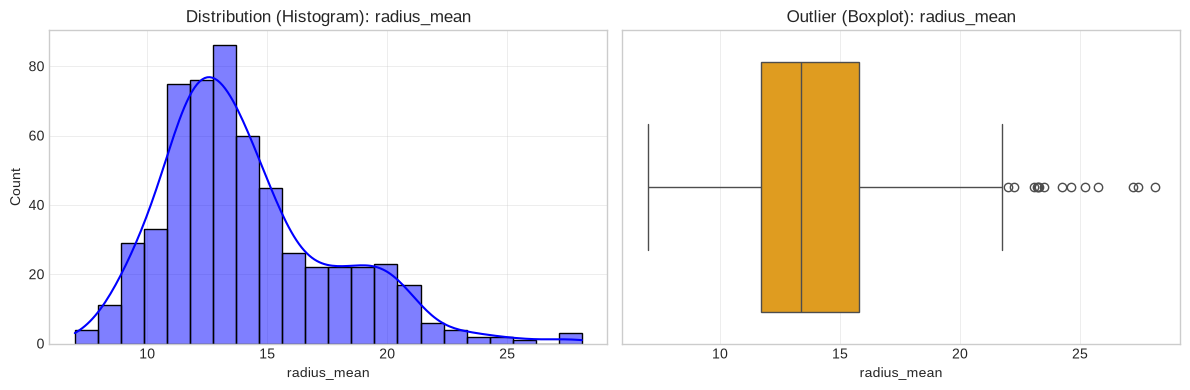

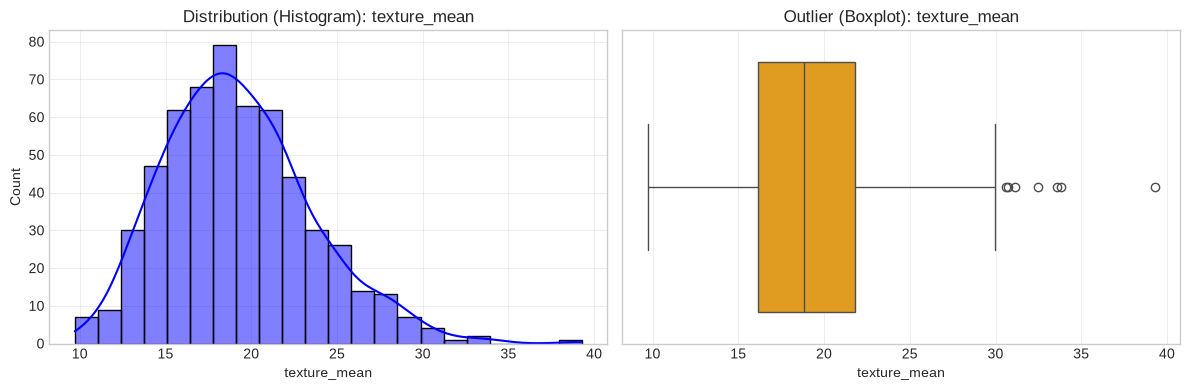

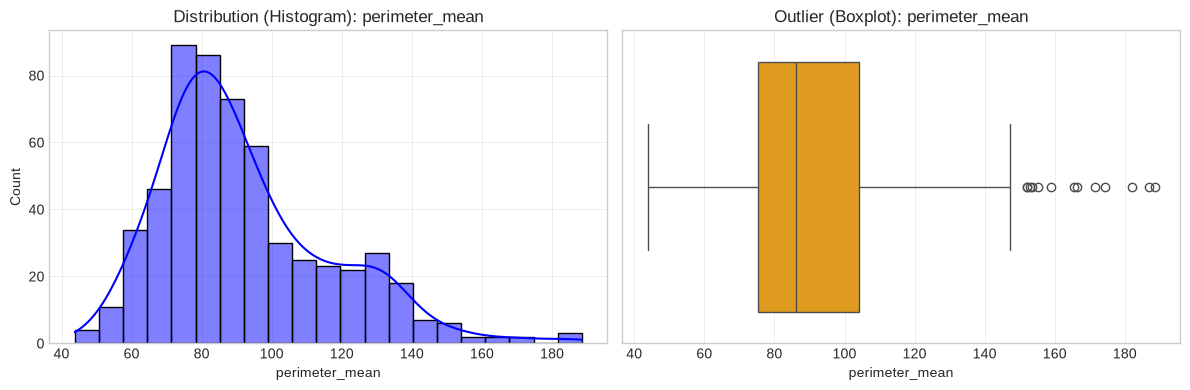

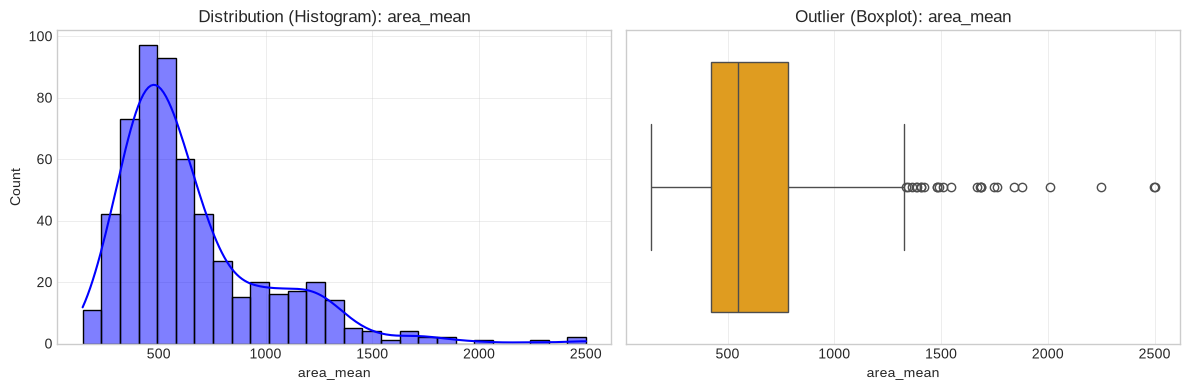

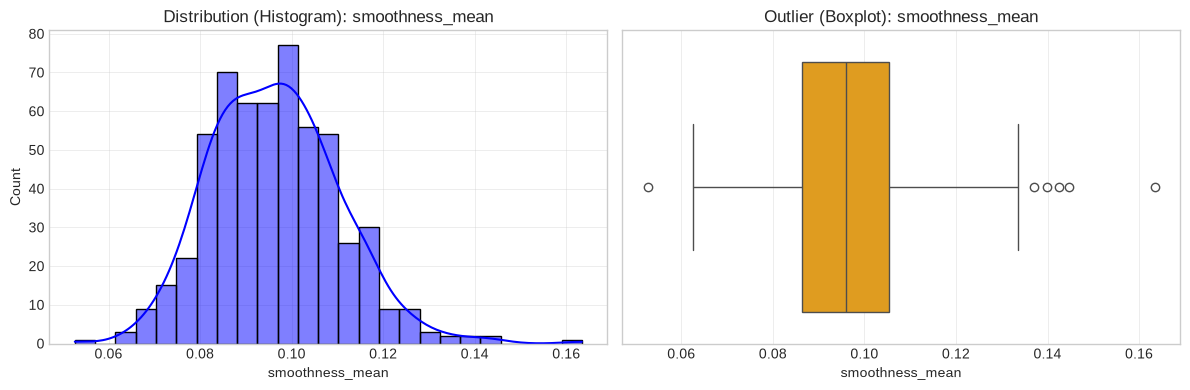

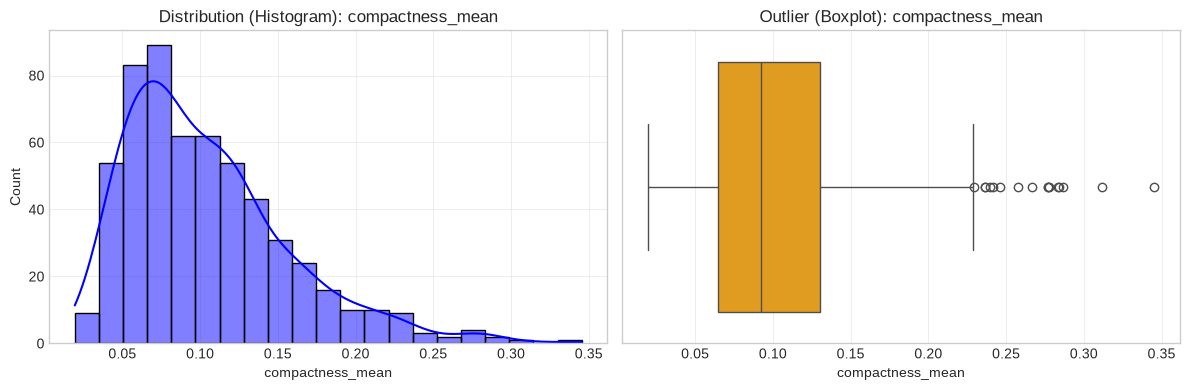

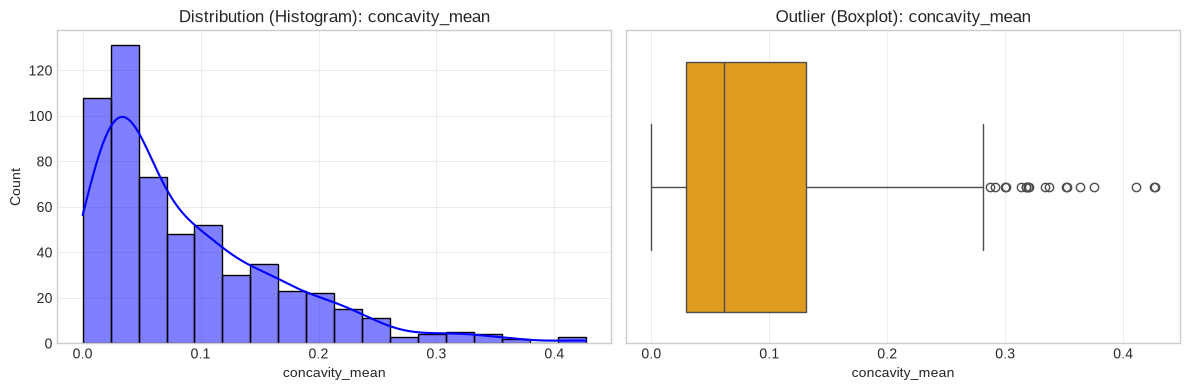

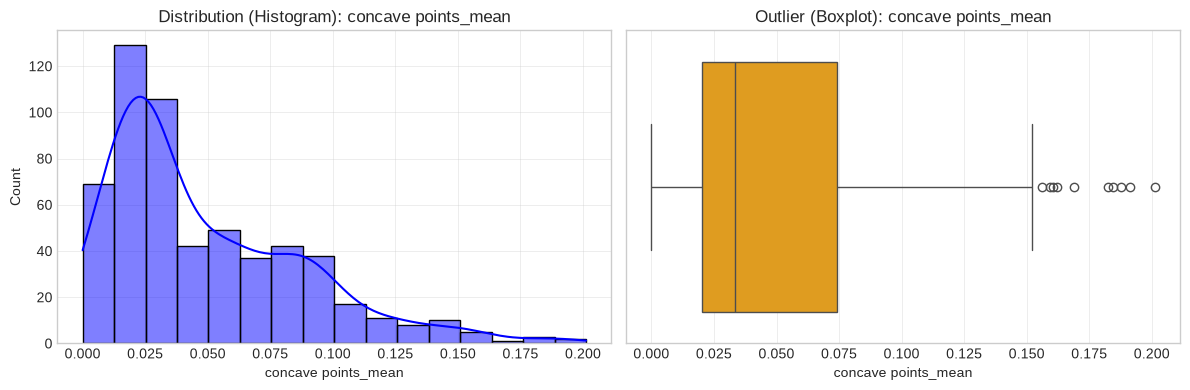

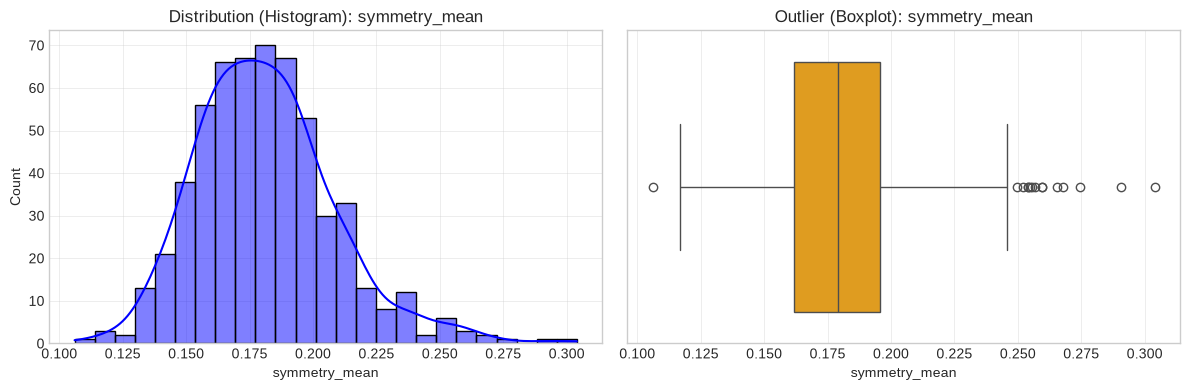

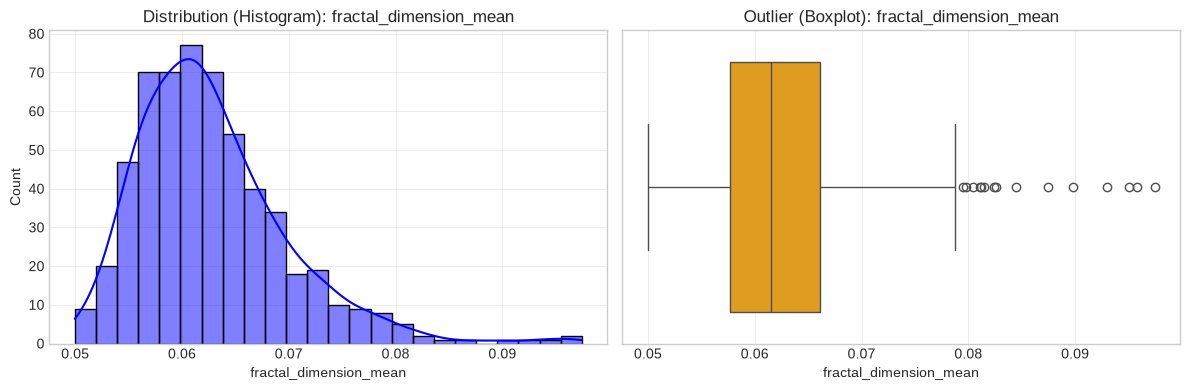

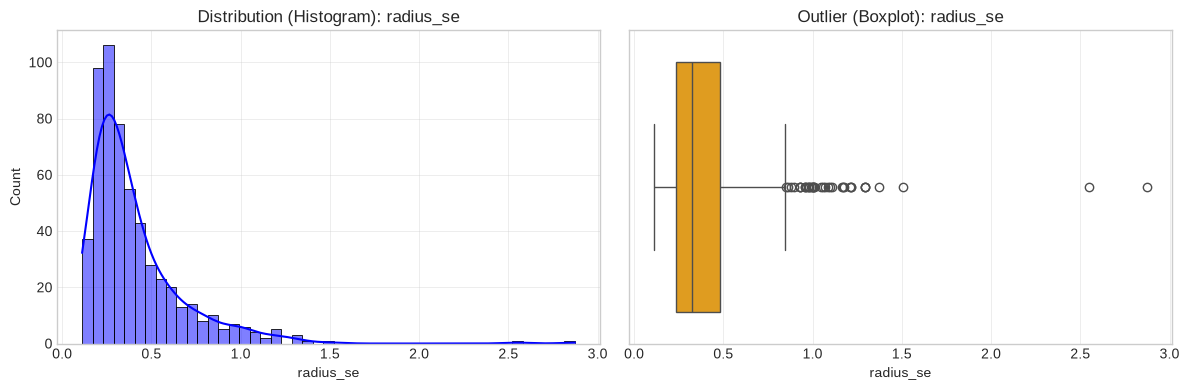

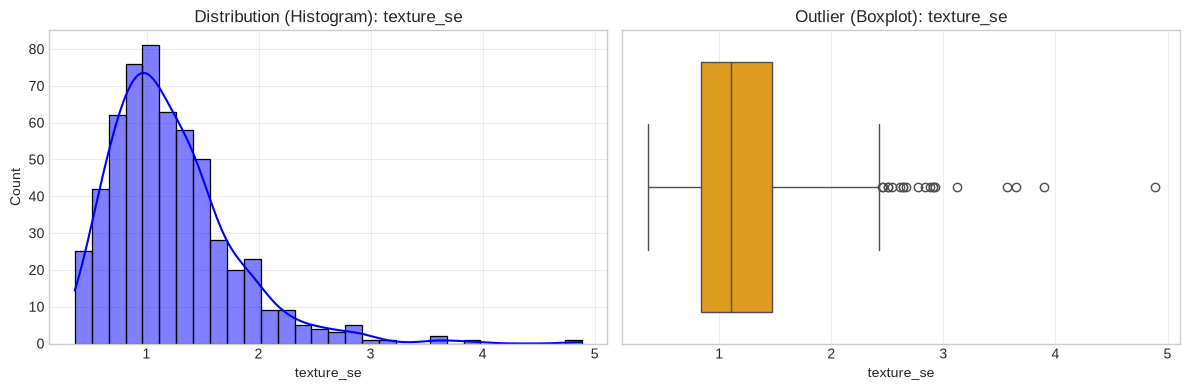

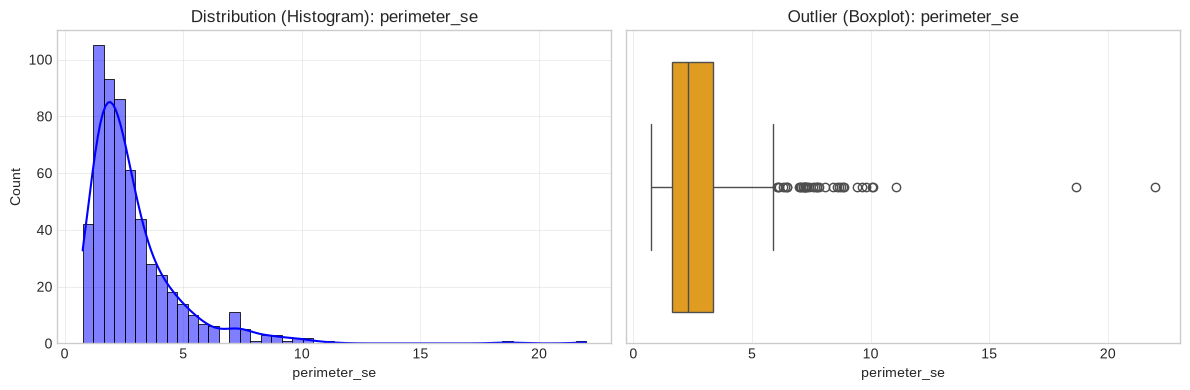

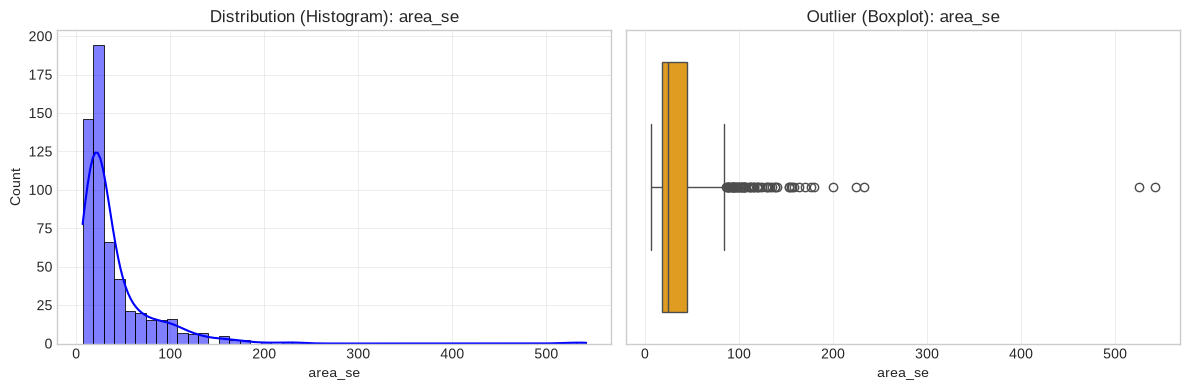

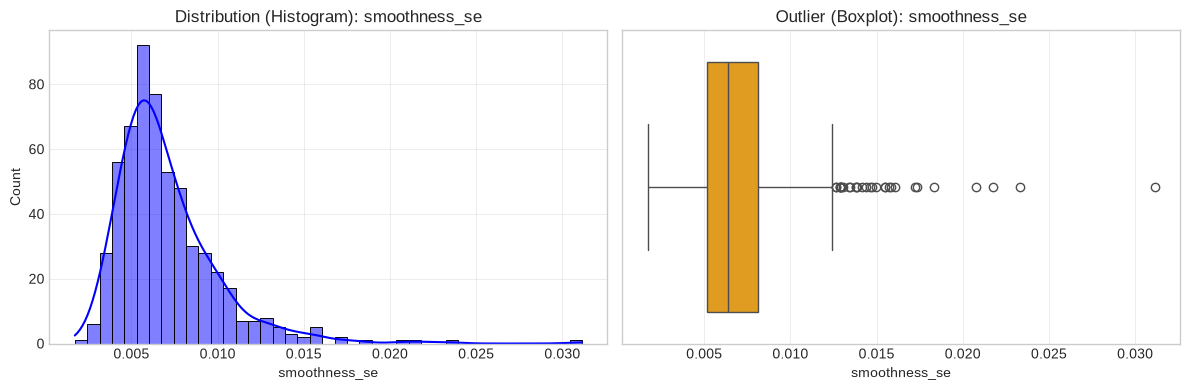

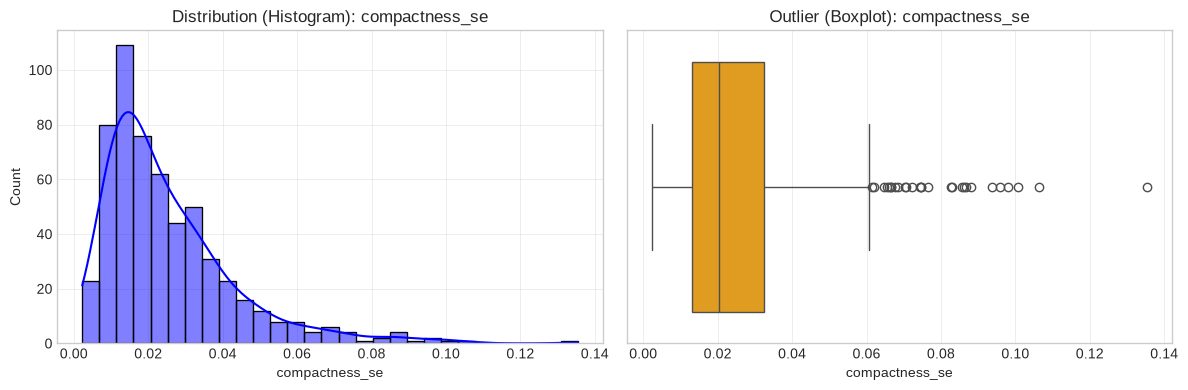

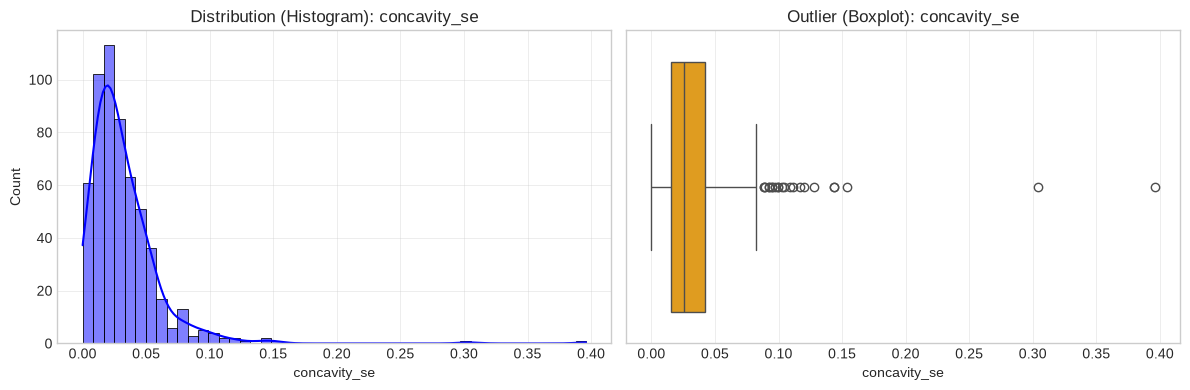

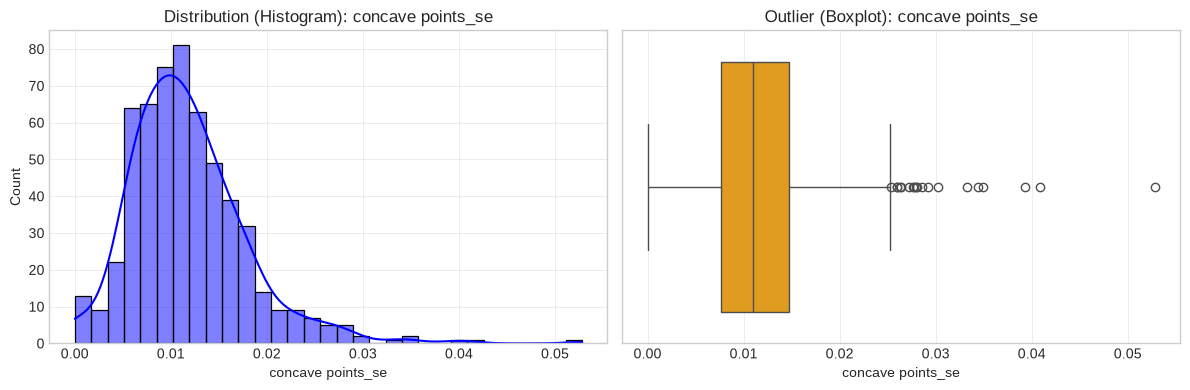

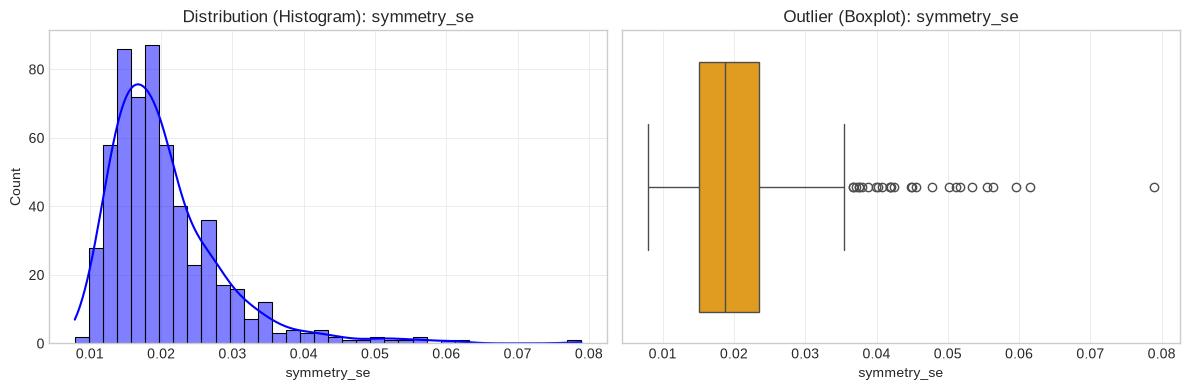

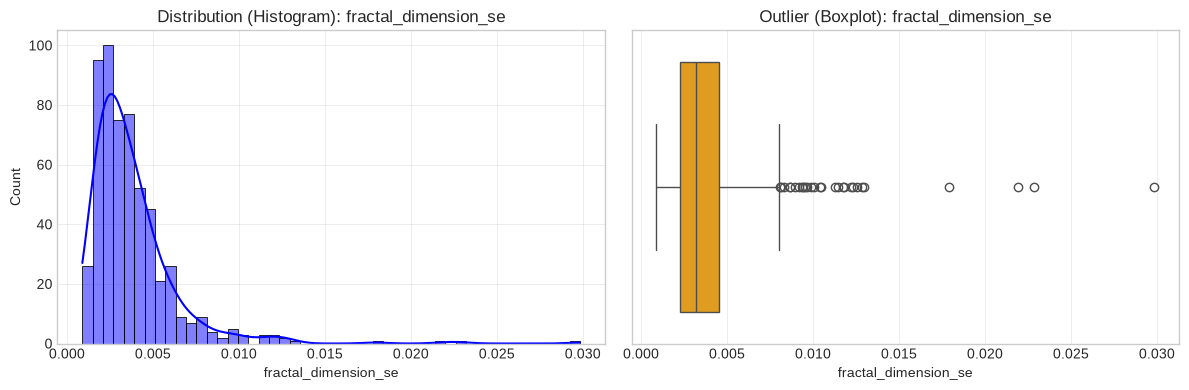

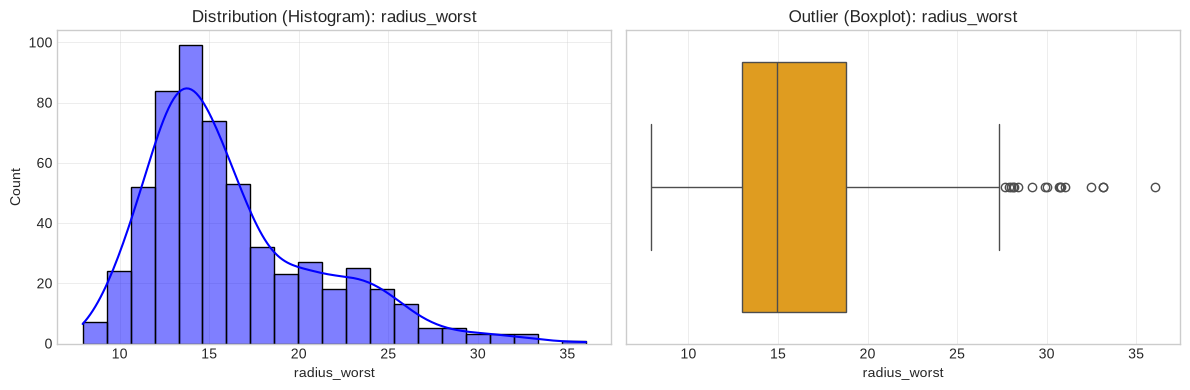

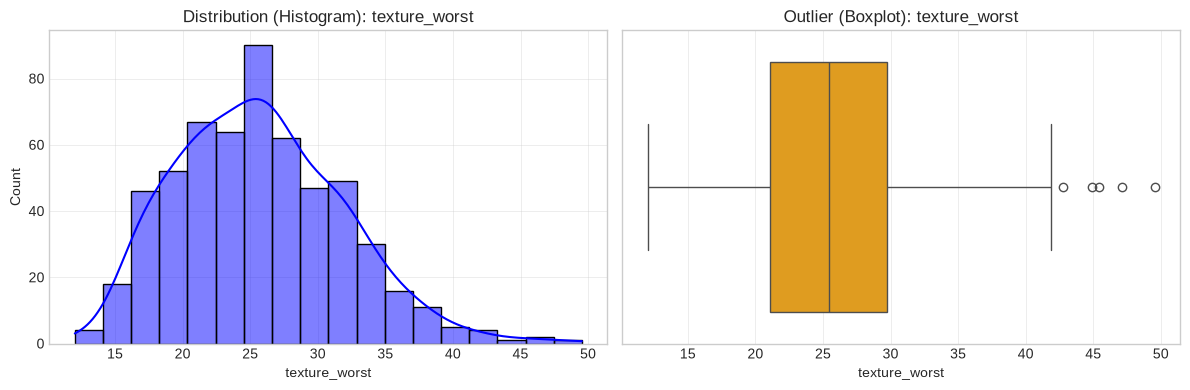

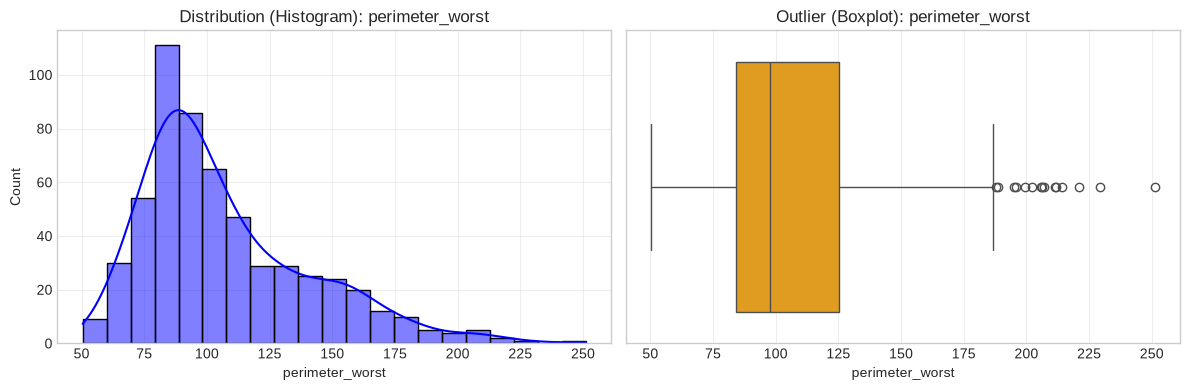

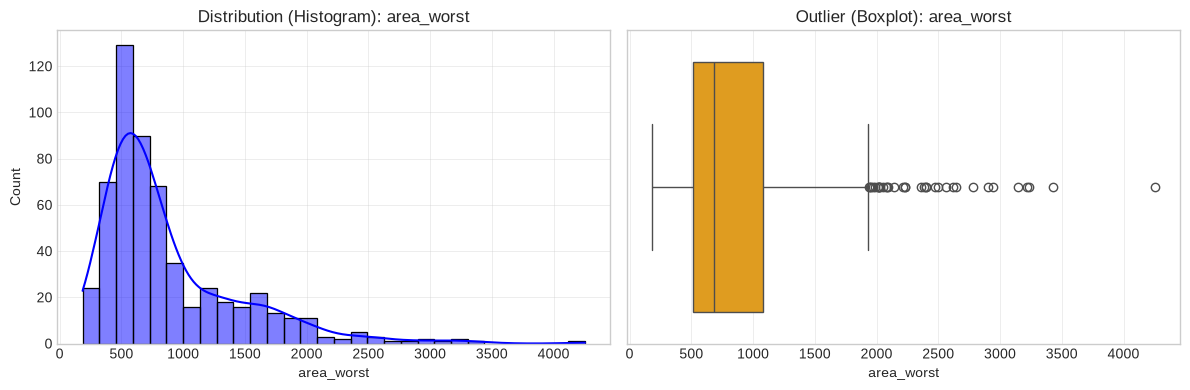

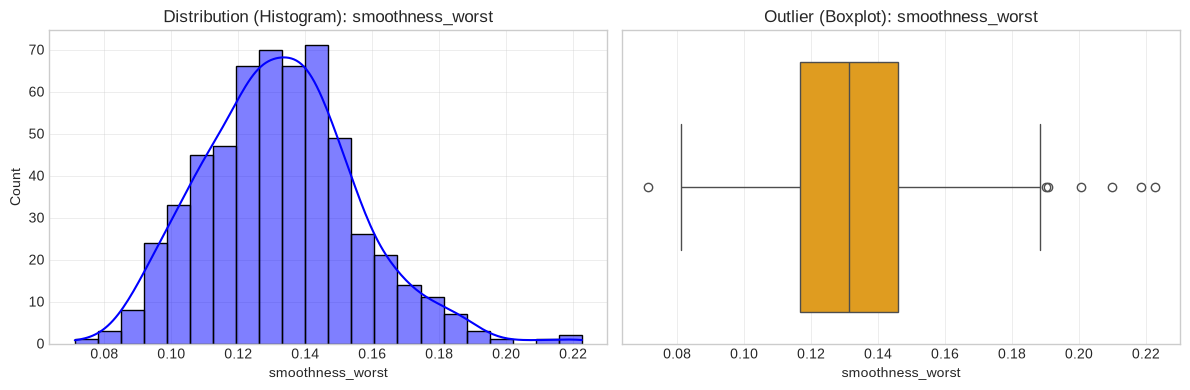

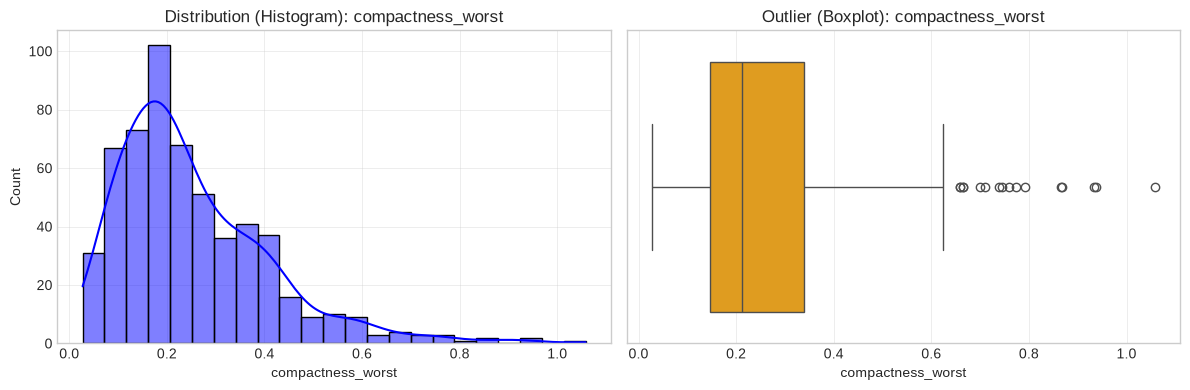

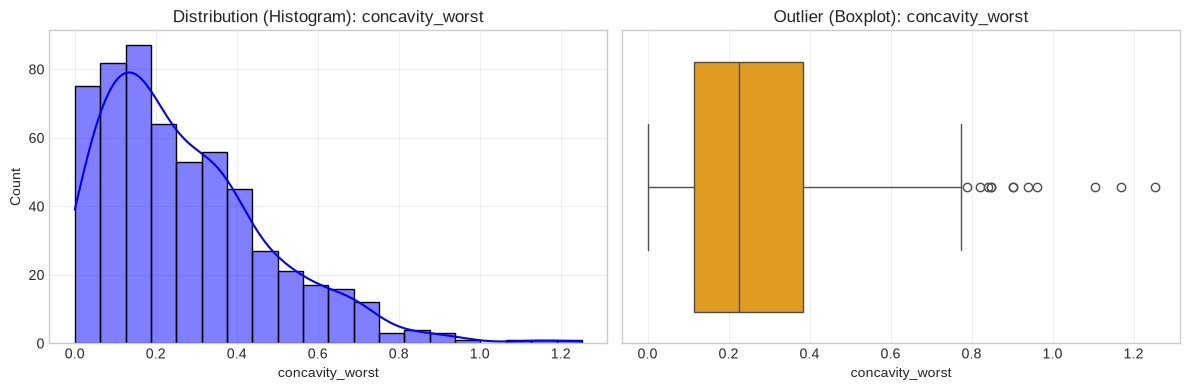

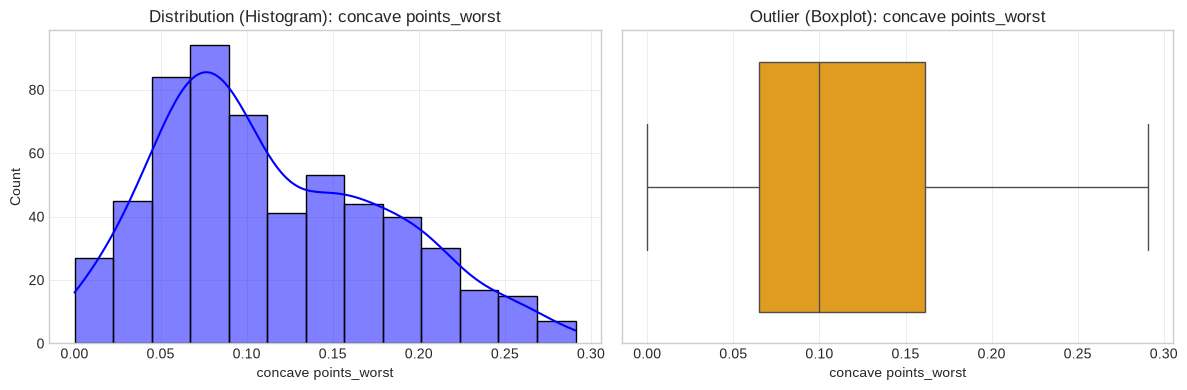

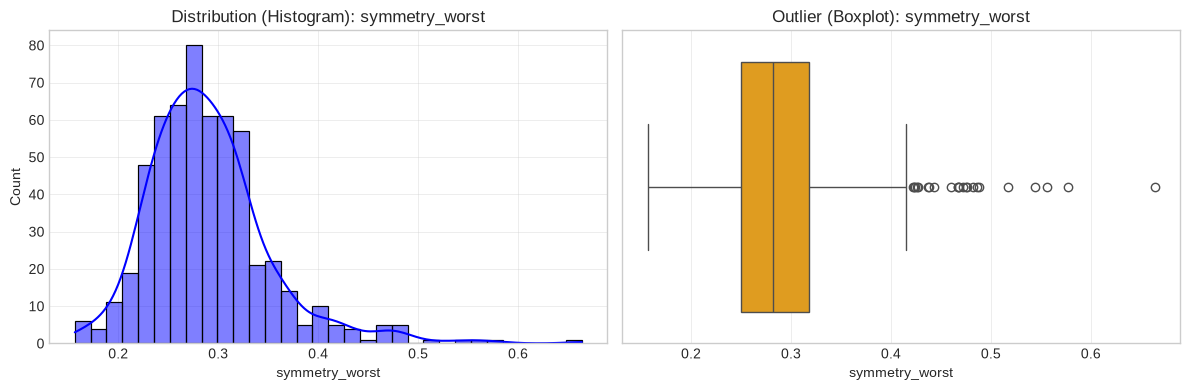

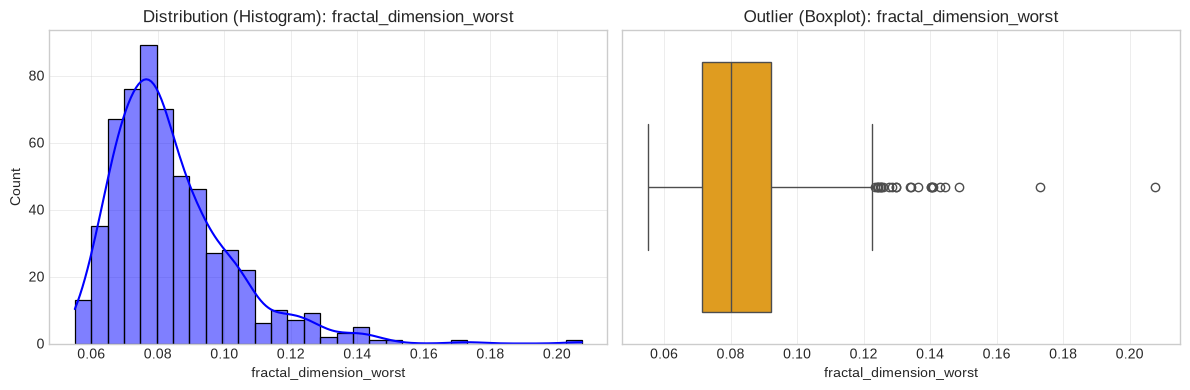

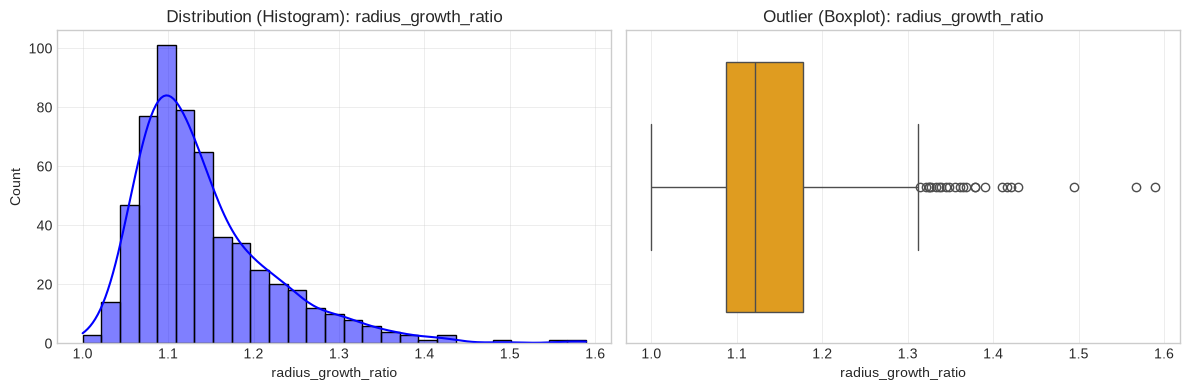

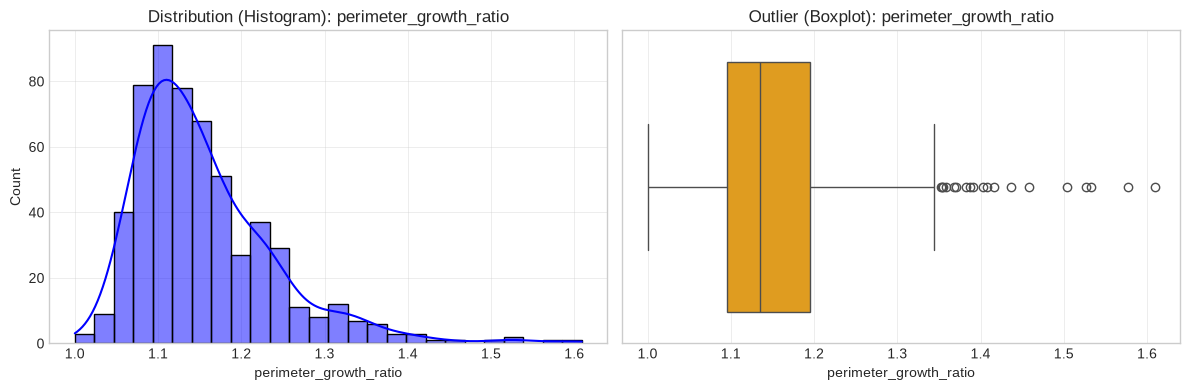

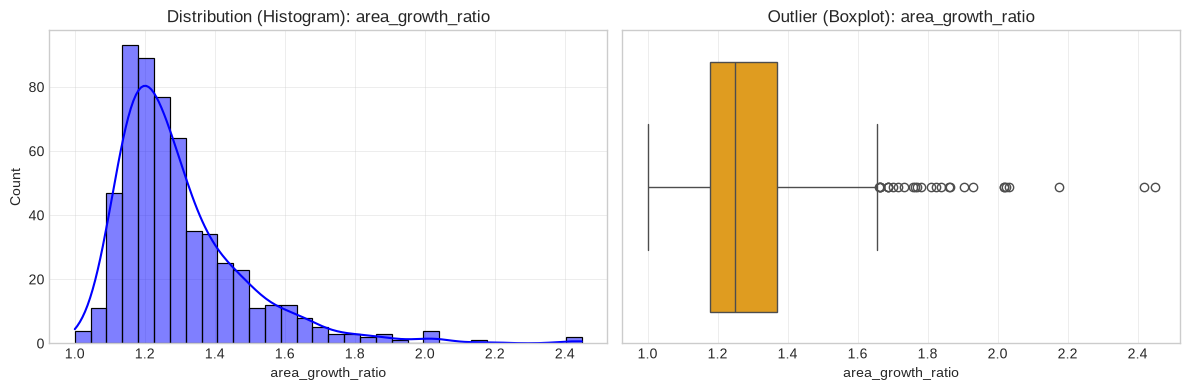

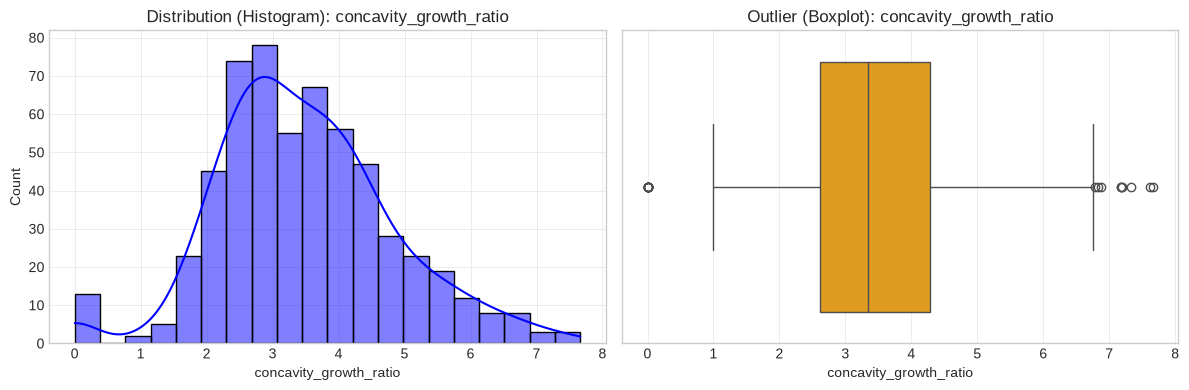

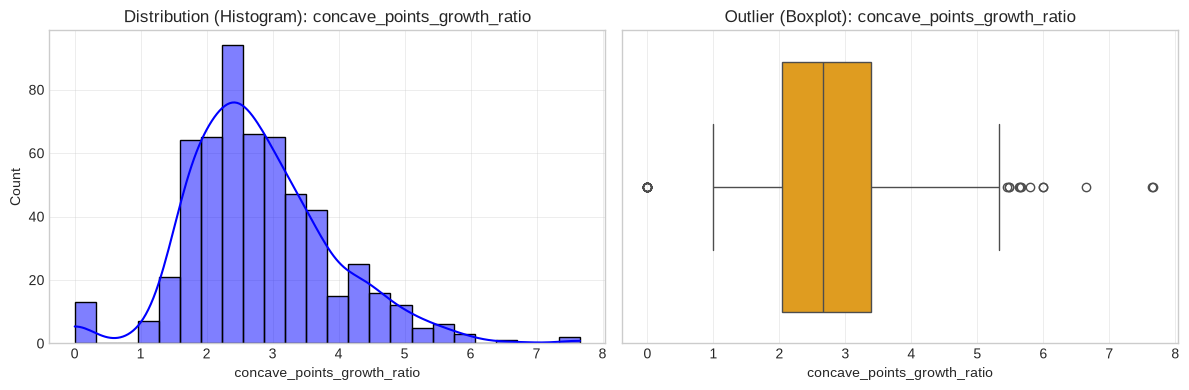

In [5]:
# --- 2.1 Statistical Distributions ---
numerical_cols = df.drop(columns=["id","Unnamed: 32","diagnosis"])
plot_statistical_distributions(df, numerical_cols)

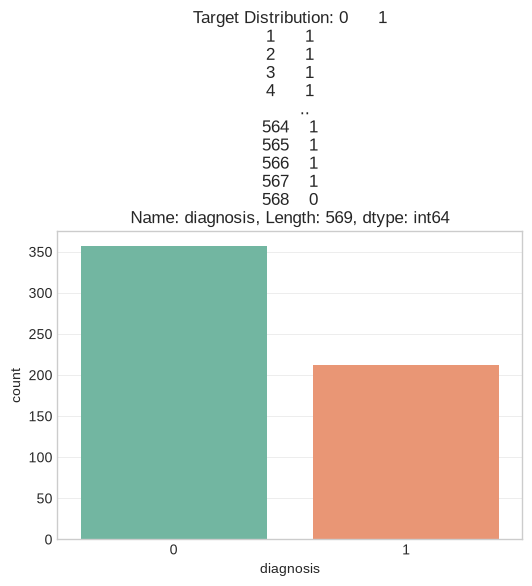

In [6]:
# --- 3. Target Distribution ---
target_column = df["diagnosis"]
plot_target_distribution(df, target_column)

In [7]:
# --- 4. Train - Test Split ---
X = df.drop(columns=["diagnosis","id"])
y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Data is splitted -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Data is splitted -> Train: (455, 36), Test: (114, 36)


In [8]:
# --- 5. Clearing Constant Columns ---
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

if constant_cols:
    print(f"Constant Columns are detected and deleted: {constant_cols}")
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
else:
    print("No Constant Columns Detected.")

Constant Columns are detected and deleted: ['Unnamed: 32']


In [9]:
# --- 6. Outlier Detection and IQR Clipping ---
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train, X_test, numerical_cols)

=== Outlier Counts ===
🔸 radius_mean: Found 11 outliers.
🔸 texture_mean: Found 5 outliers.
🔸 perimeter_mean: Found 12 outliers.
🔸 area_mean: Found 20 outliers.
🔸 smoothness_mean: Found 5 outliers.
🔸 compactness_mean: Found 14 outliers.
🔸 concavity_mean: Found 17 outliers.
🔸 concave points_mean: Found 9 outliers.
🔸 symmetry_mean: Found 13 outliers.
🔸 fractal_dimension_mean: Found 12 outliers.
🔸 radius_se: Found 31 outliers.
🔸 texture_se: Found 15 outliers.
🔸 perimeter_se: Found 34 outliers.
🔸 area_se: Found 53 outliers.
🔸 smoothness_se: Found 20 outliers.
🔸 compactness_se: Found 24 outliers.
🔸 concavity_se: Found 24 outliers.
🔸 concave points_se: Found 17 outliers.
🔸 symmetry_se: Found 22 outliers.
🔸 fractal_dimension_se: Found 23 outliers.
🔸 radius_worst: Found 10 outliers.
🔸 texture_worst: Found 3 outliers.
🔸 perimeter_worst: Found 12 outliers.
🔸 area_worst: Found 21 outliers.
🔸 smoothness_worst: Found 3 outliers.
🔸 compactness_worst: Found 15 outliers.
🔸 concavity_worst: Found 11 out

In [10]:
# --- 7. Yeo Johnson for Skewness ---
X_train_yeo, X_test_yeo, pt = apply_yeo_johnson(X_train_clipped, X_test_clipped)

7. Yeo-Johnson transformation is applied successfully and test set is protected (Data Leakage is blocked).


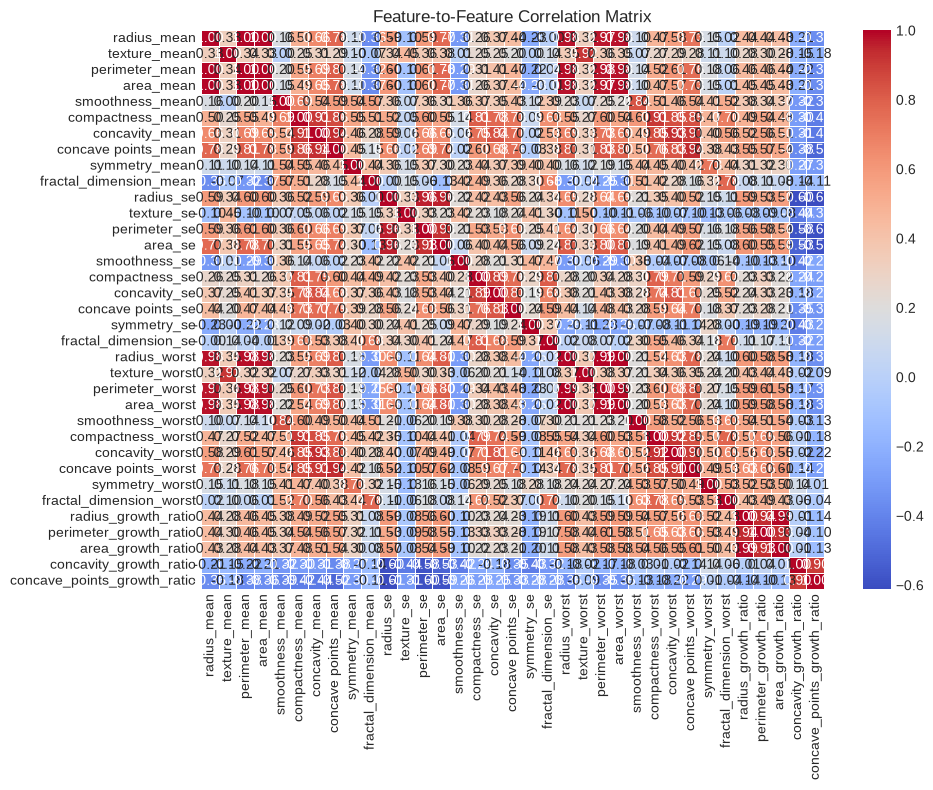

⚠️ Highly correlated (overlapping) features: ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'concavity_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'perimeter_growth_ratio', 'area_growth_ratio', 'concave_points_growth_ratio']


In [11]:
# --- 8. Feature Correlations Analyze ---
target_corr, to_drop = analyze_feature_correlations(X_train_yeo, target_col="diagnosis")

In [12]:
# --- 9. Correlation Filter ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_yeo, X_test_yeo, corr_threshold=0.85
)

9. Remaining Feature Count After Correlation Filter: 18


In [13]:
# --- 10. Feature Selection ---
selected_features = select_best_features_anova(X_train_corr,y_train, k=10)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== Top 10 Features (ANOVA / SelectKBest) ===
                Feature       Score
0           radius_mean  497.286551
16  radius_growth_ratio  330.004787
6             radius_se  291.958133
3      compactness_mean  280.883392
10    concave points_se  122.171539
13     smoothness_worst  102.906149
1          texture_mean   99.777182
14       symmetry_worst   90.058838
2       smoothness_mean   87.344389
9        compactness_se   68.024021


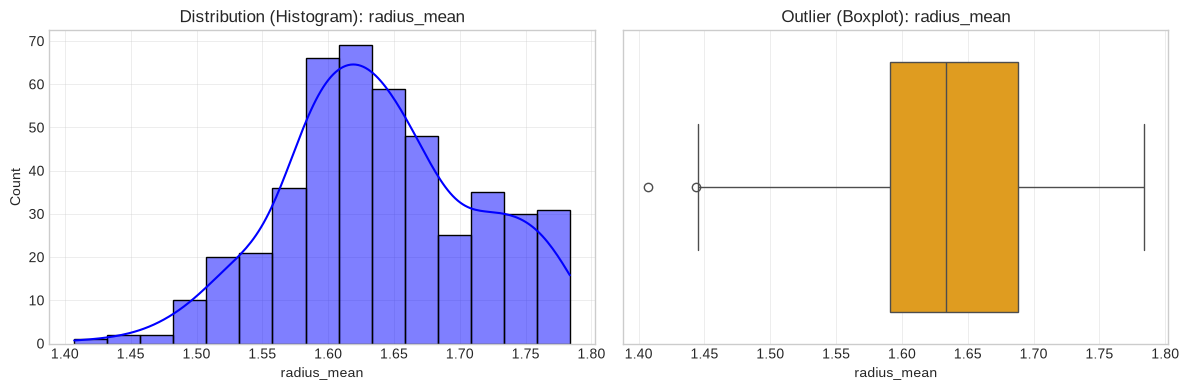

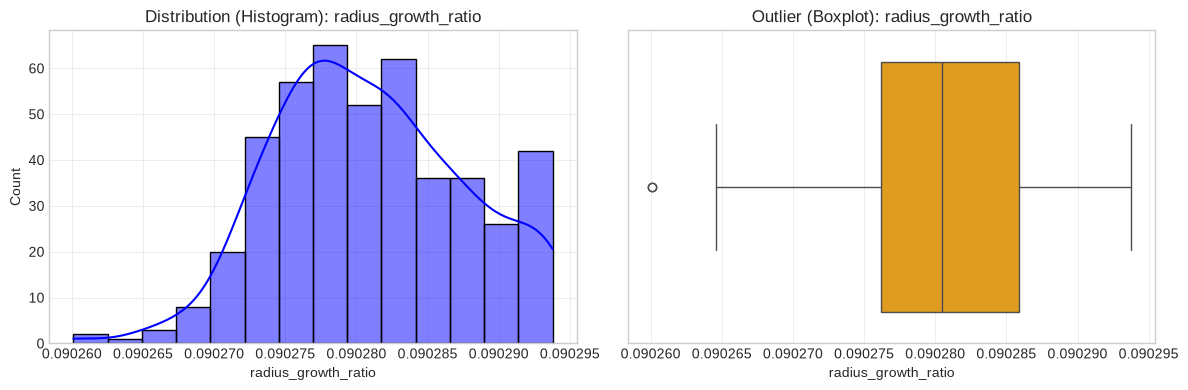

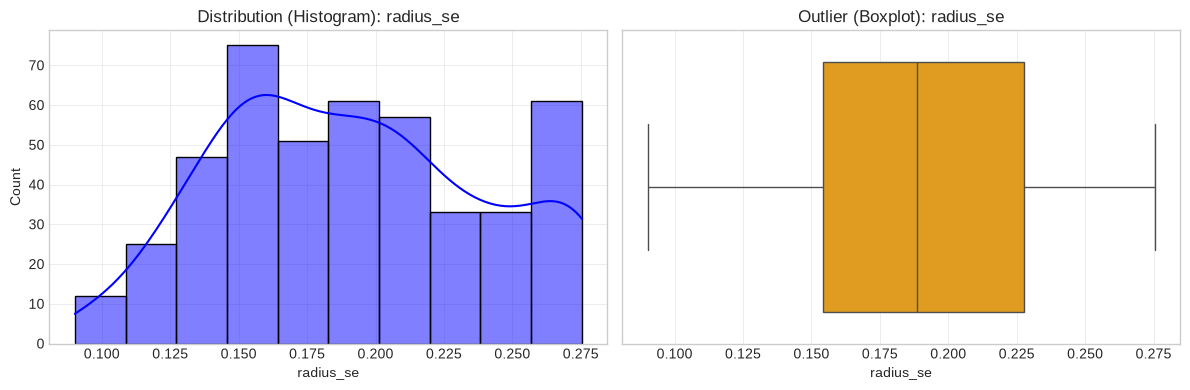

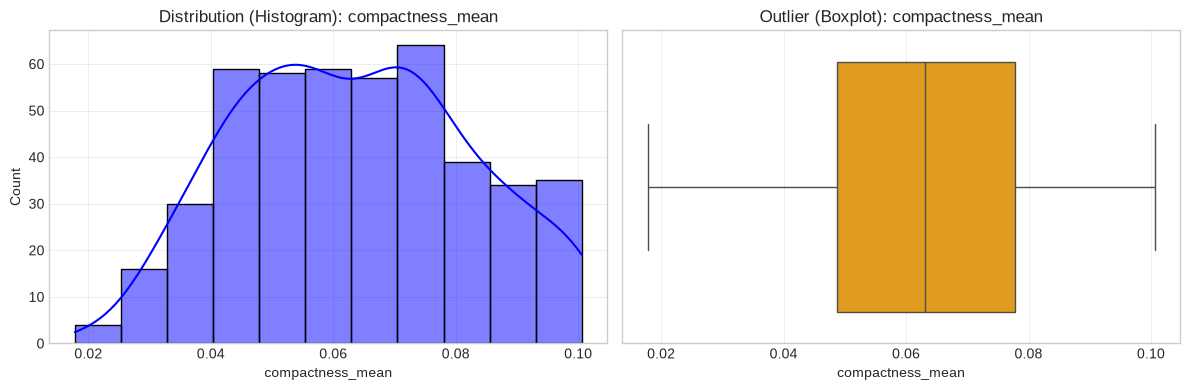

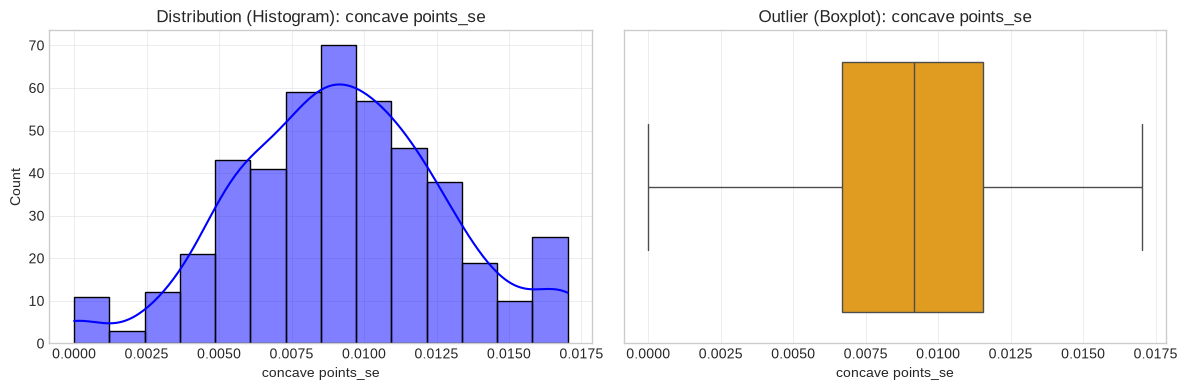

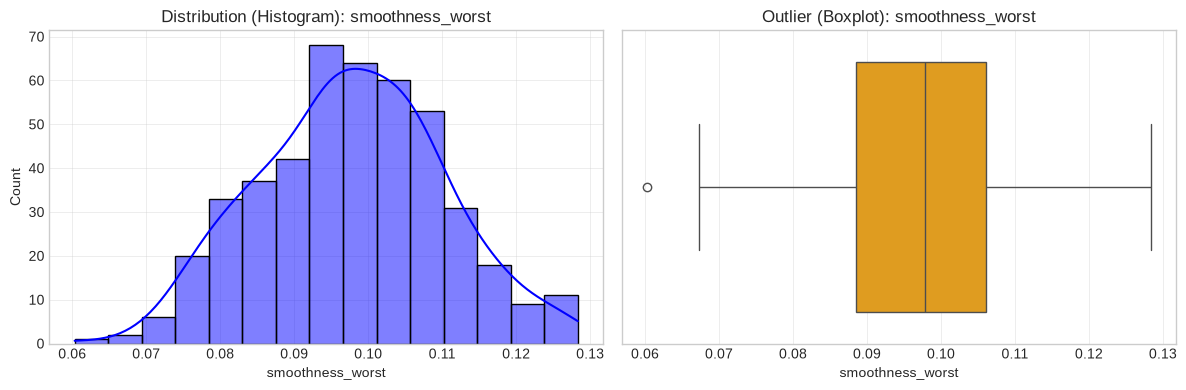

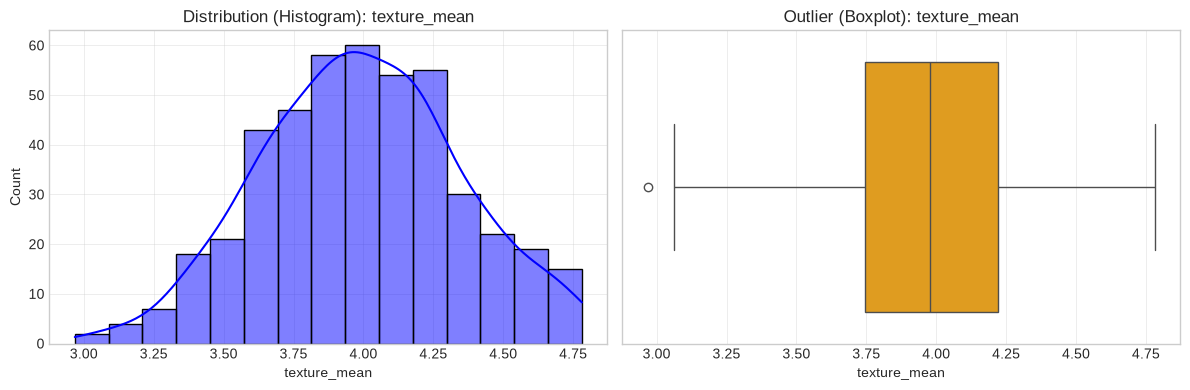

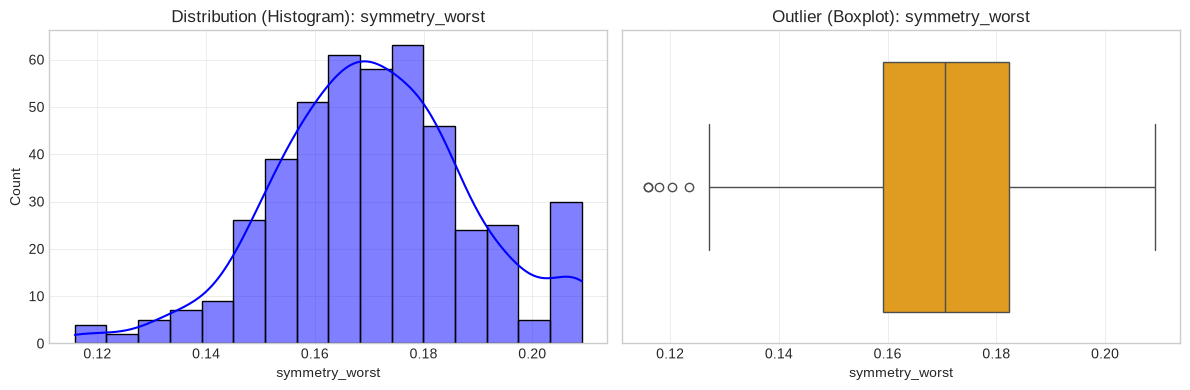

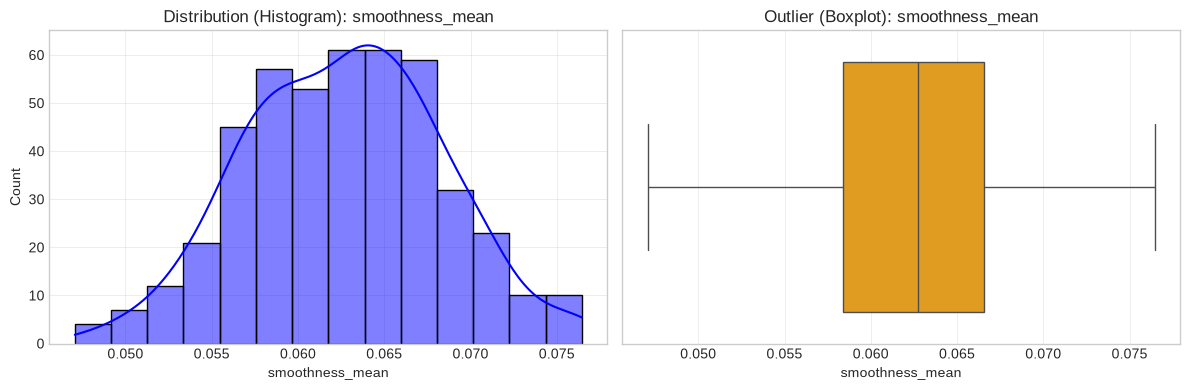

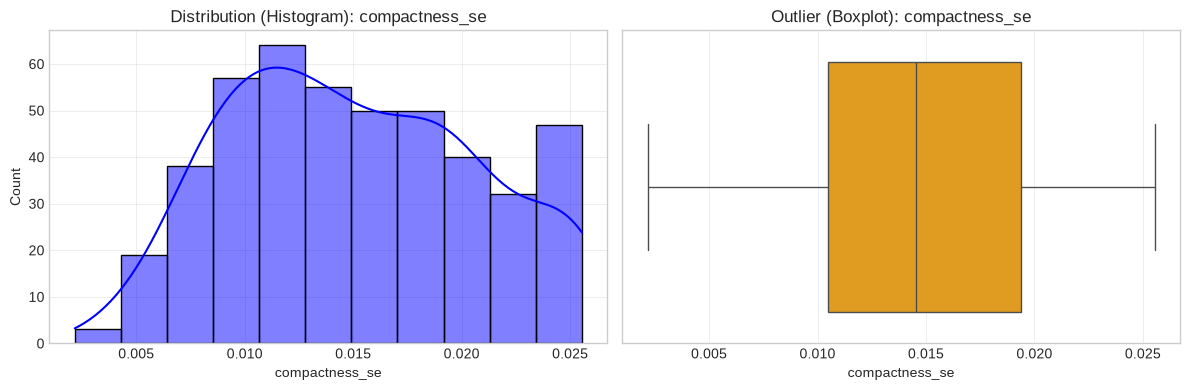

In [14]:
# --- 11. Virtualization
plot_statistical_distributions(X_train_selected, selected_features)

In [15]:
# --- 12. Scaling ---
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

In [16]:
# All in Bundle
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
    "pt": pt,
    "scaler": scaler,
    "selected_features": selected_features,
}
# Tek dosyaya kaydet
joblib.dump(bundle, "../backend/models/cancer/cancer_data_bundle.pkl")
print(
    "Processed cancer dataset is successfully loaded to: backend/models/cancer/"
)

Processed cancer dataset is successfully loaded to: backend/models/cancer/
